In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
OUTPATH = "../../output/results-summary-091924/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
# internet access
anes_all["it_access"] = anes_all["it_access"].replace(5, 0)
anes_all["it_access"] = anes_all["it_access"].replace(9, np.NaN)
anes_all.head()


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_blacks,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,4.0,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,4.0,7.0,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,1.0,6.0,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,5.0,4.0,1.0,0.0,5.0,NaN,5.0,3.0,0.6005,-5.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,4.0,5.0,1.0,0.0,5.0,NaN,6.0,7.0,1.9270,70.0


In [3]:
NODE_COLS = [
    "spend_serv", "gov_health", "guar_jobs", "abort", "aid_black",
    # "immigrat", "gun_own", "spend_school", "spend_crime", "spend_welfare",
    # "spend_poor", "penalty_favopp", "gay_discr",
    # "left_right", "lbrl_cnsv"
]

COV_COLS = ["ft_rep_net"]

In [4]:
from src.polar_measures import get_modularity, get_diameter, get_pol_distance
from src.polar_measures import get_linearization, get_binary_comm, set_edge_distance

In [5]:
anes_on = anes_all[anes_all["it_access"]==1]
anes_off = anes_all[anes_all["it_access"]==0]

In [6]:
mod_ls_bstr_on = {}
dia_ls_bstr_on = {}
lin_ls_bstr_on = {}
dst_ls_bstr_on = {}

comm_attr = "ft_rep_net"
nruns = 200

for year in [2000, 2004, 2008]:
    mod_ls_bstr_on[year] = []
    dia_ls_bstr_on[year] = []
    lin_ls_bstr_on[year] = []
    dst_ls_bstr_on[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr = anes_on[anes_on["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        resin.adjust_coordinates()
        set_edge_distance(resin.g)

        comms = get_binary_comm(resin, comm_attr)
        mod = get_modularity(resin, comms)
        dia = get_diameter(resin, weight_col="distance")
        lin = get_linearization(resin)
        dst = get_pol_distance(resin)

        mod_ls_bstr_on[year].append(mod)
        dia_ls_bstr_on[year].append(dia)
        lin_ls_bstr_on[year].append(lin)
        dst_ls_bstr_on[year].append(dst)

# for five items it's going to take ~ 5m31s

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [7]:
mod_ls_bstr_off = {}
dia_ls_bstr_off = {}
lin_ls_bstr_off = {}
dst_ls_bstr_off = {}

comm_attr = "ft_rep_net"
nruns = 200

for year in [2000, 2004, 2008]:
    mod_ls_bstr_off[year] = []
    dia_ls_bstr_off[year] = []
    lin_ls_bstr_off[year] = []
    dst_ls_bstr_off[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr = anes_off[anes_off["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        resin.adjust_coordinates()
        set_edge_distance(resin.g)

        comms = get_binary_comm(resin, comm_attr)
        mod = get_modularity(resin, comms)
        dia = get_diameter(resin, weight_col="distance")
        lin = get_linearization(resin)
        dst = get_pol_distance(resin)

        mod_ls_bstr_off[year].append(mod)
        dia_ls_bstr_off[year].append(dia)
        lin_ls_bstr_off[year].append(lin)
        dst_ls_bstr_off[year].append(dst)

# for five items it's going to take ~ 5m31s

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [8]:
def clean_nan(arr):
    clean_arr = []
    for vals in arr:
        filter_arr = [x for x in vals if str(x)!="nan"]
        clean_arr.append(filter_arr)
    return clean_arr 

In [18]:
dst_ls_bstr_avg_on = list(np.mean(np.array(list(dst_ls_bstr_on.values())), axis=2))
dst_ls_bstr_avg_off = list(np.mean(np.array(list(dst_ls_bstr_off.values())), axis=2))

In [19]:
dst_ls_bstr_avg_on 

[array([1.62613842, 1.67590017, 1.71156411, 1.65407282, 1.69157044,
        1.66935318, 1.66045613, 1.65596525, 1.66943411, 1.68512181,
        1.67829241, 1.66736346, 1.66013759, 1.69268229, 1.70244239,
        1.64277149, 1.66019491, 1.71060363, 1.64891164, 1.67505553,
        1.68552118, 1.68651392, 1.65664259, 1.65680471, 1.65837957,
        1.66278561, 1.68800324, 1.66833237, 1.66819319, 1.63920592,
        1.63945739, 1.64607094, 1.68706434, 1.68147893, 1.6596922 ,
        1.65736513, 1.64963635, 1.68842795, 1.66606246, 1.6747155 ,
        1.64666631, 1.68677254, 1.66990842, 1.65243693, 1.68206517,
        1.67430523, 1.65437276, 1.65898249, 1.66917043, 1.66650234,
        1.66060915, 1.64067624, 1.65626129, 1.62414636, 1.63871381,
        1.68809761, 1.67620802, 1.65881542, 1.65074088, 1.68383357,
        1.69042907, 1.65236974, 1.67947131, 1.63647466, 1.65035324,
        1.65450813, 1.64944469, 1.68640515, 1.6507831 , 1.69725306,
        1.64907028, 1.67268353, 1.67074888, 1.65

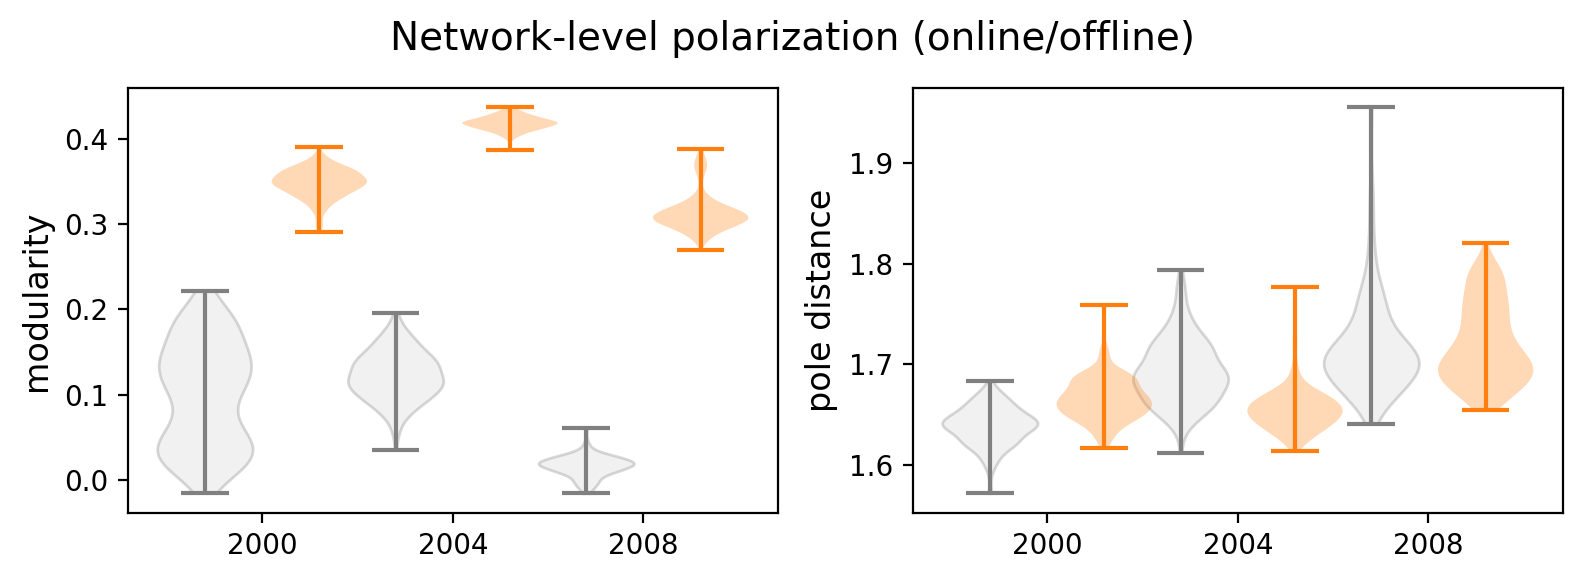

In [21]:
fig,ax = plt.subplots(ncols=2, figsize=(8,3))
vp00 = ax[0].violinplot(clean_nan(mod_ls_bstr_off.values()), positions=np.arange(1,4)-.3)
vp01 = ax[0].violinplot(clean_nan(mod_ls_bstr_on.values()), positions=np.arange(1,4)+.3)
vp10 = ax[1].violinplot(clean_nan(dst_ls_bstr_avg_off), positions=np.arange(1,4)-.3)
vp11 = ax[1].violinplot(clean_nan(dst_ls_bstr_avg_on), positions=np.arange(1,4)+.3)
for vp in [vp00, vp10]:
    for pc in vp["bodies"]:
        pc.set_facecolor("lightgrey")
        pc.set_edgecolor("grey")
    for elem in ("cbars","cmins","cmaxes"):
        vp[elem].set_edgecolor("grey")
        
ax[0].set_ylabel("modularity", fontsize=12)
ax[1].set_ylabel("pole distance", fontsize=12)
for i in [0,1]:
    ax[i].set_xticks(range(1,4), [2000, 2004, 2008])
plt.suptitle("Network-level polarization (online/offline)", fontsize=14, y=.95)
plt.tight_layout()
# plt.show()
# plt.savefig(OUTPATH + "network-level-polar-ONOFFLINE.png", dpi=300, bbox_inches="tight")